In [50]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [2]:
don2 = pd.read_csv("donclassif2.txt", header=0, sep=";")
don2.shape

(70000, 2)

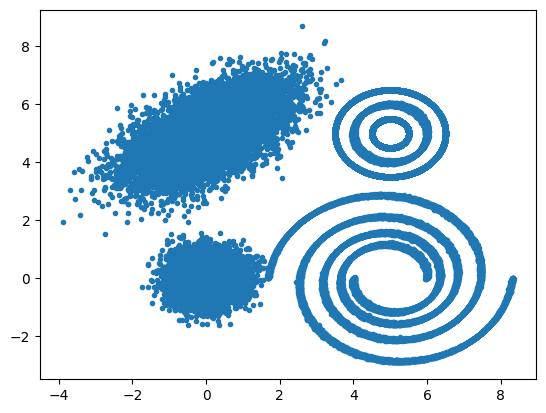

In [51]:
plt.plot(don2["V1"],don2["V2"],'.')
plt.show()

In [52]:
tmp = KMeans(n_clusters=5000, n_init=10, random_state=0).fit(don2)

In [55]:
labelsinit = tmp.labels_
centres = tmp.cluster_centers_
centres[:2,:]

array([[-0.01130994, -0.3084894 ],
       [ 5.28360611,  5.41172512]])

Je fais une hiérarchique sur les centres

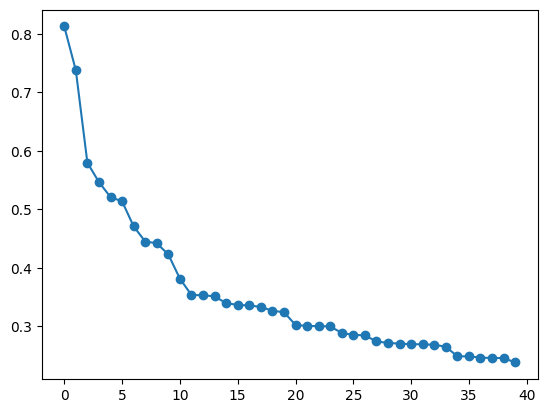

In [56]:
hiera_sim = linkage(centres,method='single')
heights = np.sort(hiera_sim[:,2])[::-1]
plt.plot(heights[:40], marker="o")

In [57]:
labels = fcluster(hiera_sim,34, criterion="maxclust")
pd.Series(labels).value_counts()

14    1835
2     1685
1      686
29     343
28     282
7      130
12       6
11       3
13       3
6        2
10       2
8        1
30       1
32       1
34       1
27       1
33       1
16       1
25       1
19       1
31       1
22       1
15       1
24       1
4        1
23       1
21       1
5        1
20       1
26       1
17       1
18       1
3        1
9        1
Name: count, dtype: int64

In [58]:
labelspd = pd.Series(labels)
counts = labelspd.value_counts()
mapping = {old_label: new_label+1 for new_label, old_label in enumerate(counts.index)}
labels_ordered = labelspd.map(mapping).values
pd.Series(labels_ordered).value_counts()

1     1835
2     1685
3      686
4      343
5      282
6      130
7        6
8        3
9        3
10       2
11       2
12       1
13       1
14       1
15       1
16       1
17       1
18       1
19       1
20       1
21       1
22       1
23       1
24       1
25       1
26       1
27       1
28       1
29       1
30       1
31       1
32       1
33       1
34       1
Name: count, dtype: int64

1    1835
2    1685
3     686
4     343
5     282
6     130
7      39
Name: count, dtype: int64


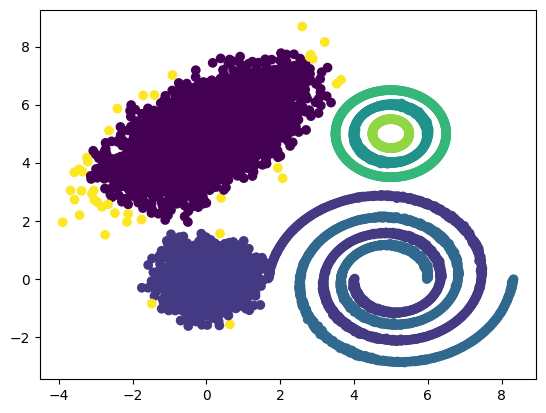

In [59]:
counts = np.bincount(labels_ordered)  # attention si labels = 0..K
labelsfin = labels_ordered.copy()
labelsfin[labelsfin>6] = 7
print(pd.Series(labelsfin).value_counts())
plt.scatter(centres[:,0],centres[:,1],c=labelsfin)
plt.show()

et je reviens aux données initiales

In [60]:
labels_indiv = labelsfin[labelsinit]
labels_indiv.shape

(70000,)

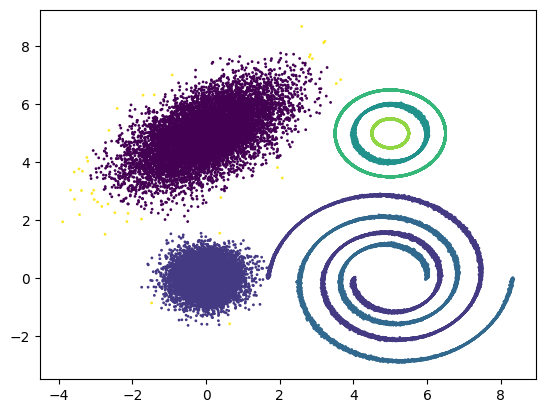

In [62]:
plt.scatter(don2["V1"], don2["V2"], c=labels_indiv,s=1)
plt.show()